In [1]:
%matplotlib notebook
import torch
import torch.nn as nn
import torch.optim as optim
from dimensionality_reduction import AE, AETrainer

In [2]:
ae = AE(1,64)
optimi = optim.Adam(ae.parameters(), lr=1e-1, weight_decay=1e-6)
sched = optim.lr_scheduler.StepLR(optimi, 50)
loss_fn = nn.MSELoss()

In [3]:
trainer = AETrainer(ae, optimi, loss_fn, 200, 32, "training_data_15.npz", scheduler=None)

In [4]:
%%time
trainer.load_data()

CPU times: total: 46 s
Wall time: 2min 32s


<IPython.core.display.Javascript object>


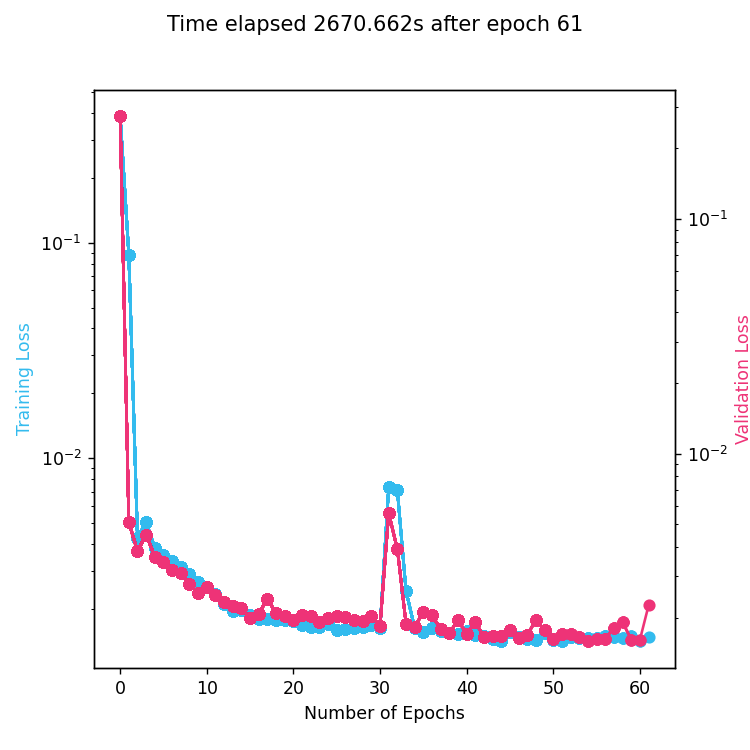

  2%|█▎                                                                                 | 1/63 [00:01<01:40,  1.62s/it]


RuntimeError: [enforce fail at ..\c10\core\CPUAllocator.cpp:76] data. DefaultCPUAllocator: not enough memory: you tried to allocate 268435456 bytes.

In [5]:
trainer.myth_trainer()

In [ ]:
ae.load_state_dict(torch.load("199_no_scheduler_1e-2.pth")["model_state_dict"])

In [ ]:
with torch.no_grad():
    out = ae(torch.from_numpy(trainer.val_in[-1]/255).unsqueeze(0).unsqueeze(0).float().cuda()).squeeze().cpu().numpy()

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
fig = plt.figure()
ax1 = fig.add_subplot(1,2,1)
ax1.imshow(trainer.val_in[-1], cmap="Greys_r")
ax2 = fig.add_subplot(1,2,2)
ax2.imshow(out, cmap="Greys_r")